In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# --------------------------------------------------------
# CORE LIBRARIES
# --------------------------------------------------------
import pandas as pd
import numpy as np

# --------------------------------------------------------
# VISUALIZATION LIBRARIES (for your Seaborn/Matplotlib requirement)
# --------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid') # Sets a professional look for charts

# --------------------------------------------------------
# MACHINE LEARNING LIBRARIES (for Logistic Regression & Random Forest)
# --------------------------------------------------------
from sklearn.model_selection import train_test_split # To split data
from sklearn.preprocessing import StandardScaler, OneHotEncoder # To preprocess data
from sklearn.linear_model import LogisticRegression # Your first model
from sklearn.ensemble import RandomForestClassifier # Your second model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score # To evaluate models
from sklearn.pipeline import Pipeline # To combine steps professionally
from sklearn.compose import ColumnTransformer # To handle different column types

print("All essential libraries imported successfully.")

All essential libraries imported successfully.


In [5]:
from google.colab import files
print("Running file uploader...")
uploaded = files.upload()
# NOTE: A 'Choose Files' button should appear below this cell. Click it and select your 'WA_Fn-UseC_-Telco-Customer-Churn.csv' file.

Running file uploader...


Saving WA_Fn-UseC_-Telco-Customer-Churn (1).csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [7]:
import os
print("Files in the current directory:")
print(os.listdir('.'))

Files in the current directory:
['.config', 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv', 'sample_data']


In [8]:
# The EXACT file name, including the (1), as confirmed by os.listdir()
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv'

try:
    # 1. Load the dataset into a Pandas DataFrame using the correct name
    df = pd.read_csv(file_name)
    print("Dataset loaded successfully!")

    # 2. Proceed with the necessary initial cleaning (from Step 2.3)
    # Convert 'TotalCharges' to numeric, coercing errors to NaN
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    # Fill NaNs (for tenure=0 customers) with 0
    df['TotalCharges'] = df['TotalCharges'].fillna(0)
    # Drop the irrelevant customer identifier
    df = df.drop('customerID', axis=1)

    # 3. Display the shape and info
    print(f"\nDataset Shape: {df.shape}")
    print("\nDataFrame Information:")
    df.info()

except FileNotFoundError:
    # This should now never run, but kept for robustness
    print(f"FATAL ERROR: The file '{file_name}' was NOT found.")
    print("Please check the os.listdir() output again.")

# Remove the 'Churn' column and the 'Churn_Numeric' column from X when preparing for modeling
if 'df' in locals():
    # Define the target variable Y and the feature set X (as done in Step 3.4)
    df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
    Y = df['Churn_Numeric']
    X = df.drop(['Churn', 'Churn_Numeric'], axis=1)
    print("\nData loading and cleaning is complete. Ready for Step 4.")

Dataset loaded successfully!

Dataset Shape: (7043, 20)

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  Paperless

In [9]:
# Identify Numerical and Categorical columns in X
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# The numerical features are: 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'
# The categorical features are: 'gender', 'Partner', 'Dependents', 'PhoneService', ... etc.

print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Numerical Features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the transformers for each type of feature
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create the Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any columns not specified (there shouldn't be any)
)

print("Preprocessing ColumnTransformer defined successfully.")

Preprocessing ColumnTransformer defined successfully.


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing sets
# stratify=Y ensures both sets have the same proportion of Churn (important for imbalanced data)
# random_state=42 ensures your results are reproducible
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("Data successfully split into training and testing sets.")

X_train shape: (5634, 19)
X_test shape: (1409, 19)
Data successfully split into training and testing sets.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 1. Define the Pipeline
# This runs the preprocessor (scaling and one-hot encoding) then the model
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# 2. Train the model
print("Training Logistic Regression Model...")
model_lr.fit(X_train, Y_train)
print("Training complete.")

# 3. Make predictions
Y_pred_lr = model_lr.predict(X_test)
Y_proba_lr = model_lr.predict_proba(X_test)[:, 1] # Get probabilities for ROC AUC

# 4. Evaluate the model
print("\n--- Logistic Regression Model Evaluation ---")
print(classification_report(Y_test, Y_pred_lr))
print(f"ROC AUC Score: {roc_auc_score(Y_test, Y_proba_lr):.4f}")

Training Logistic Regression Model...
Training complete.

--- Logistic Regression Model Evaluation ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC AUC Score: 0.8421


In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Pipeline
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

# 2. Train the model
print("\nTraining Random Forest Model...")
model_rf.fit(X_train, Y_train)
print("Training complete.")

# 3. Make predictions
Y_pred_rf = model_rf.predict(X_test)
Y_proba_rf = model_rf.predict_proba(X_test)[:, 1] # Get probabilities for ROC AUC

# 4. Evaluate the model
print("\n--- Random Forest Model Evaluation ---")
print(classification_report(Y_test, Y_pred_rf))
print(f"ROC AUC Score: {roc_auc_score(Y_test, Y_proba_rf):.4f}")


Training Random Forest Model...
Training complete.

--- Random Forest Model Evaluation ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC AUC Score: 0.8185


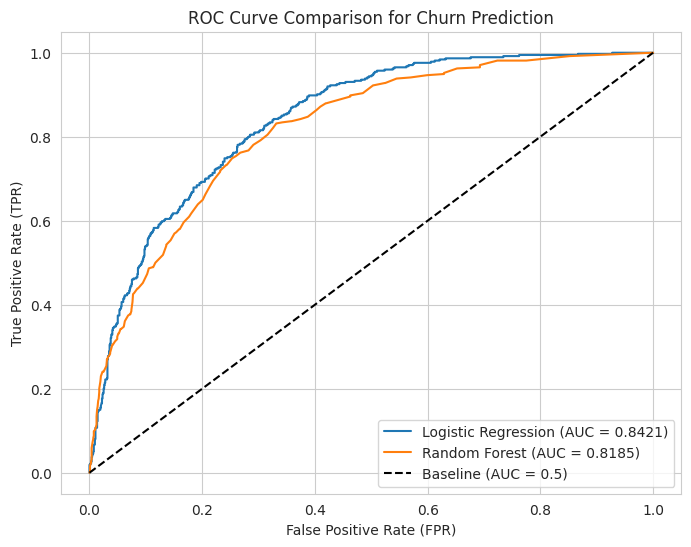

In [14]:
from sklearn.metrics import roc_curve

# Calculate ROC curve metrics
fpr_lr, tpr_lr, _ = roc_curve(Y_test, Y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, Y_proba_rf)

plt.figure(figsize=(8, 6))

# Plot Logistic Regression ROC Curve
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(Y_test, Y_proba_lr):.4f})')

# Plot Random Forest ROC Curve
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(Y_test, Y_proba_rf):.4f})')

# Plot the baseline (random) curve
plt.plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison for Churn Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/tmp/ipython-input-1573195643.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='crest')


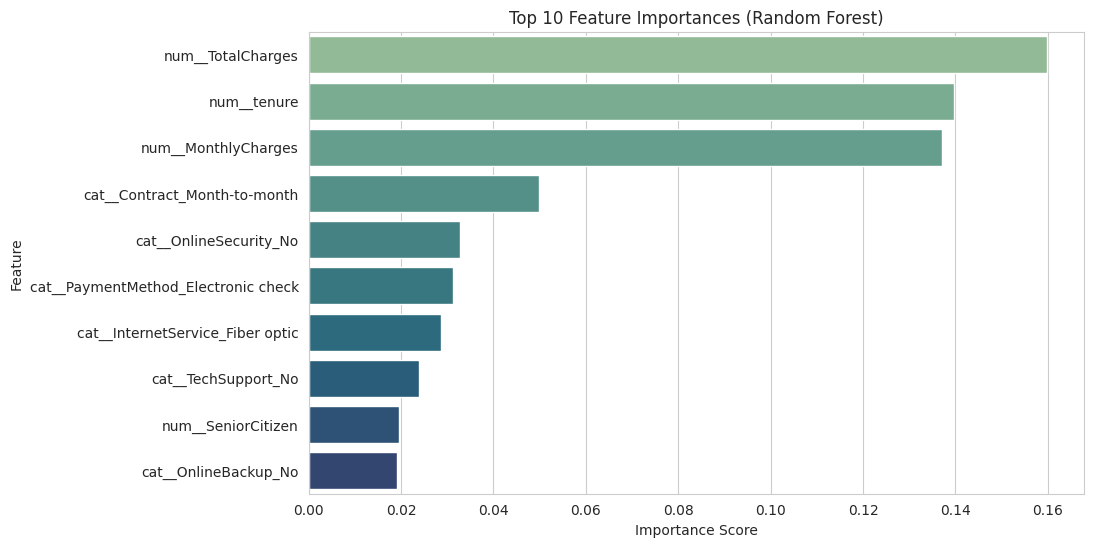

In [15]:
# Get the feature names after One-Hot Encoding and Scaling
# This step requires getting the feature names from the ColumnTransformer
feature_names_transformed = model_rf.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances from the Random Forest classifier step
importances = model_rf.named_steps['classifier'].feature_importances_

# Create a Series for easy sorting
feature_importances = pd.Series(importances, index=feature_names_transformed)

# Get the top 10 features
top_10_features = feature_importances.nlargest(10)

# Visualize the top features
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='crest')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()